In [1]:
# ========================================================
# Encrypt CSV Dataset and Store in Google Drive
# (No Blockchain Integration)
# ========================================================

import os
import json
import secrets
import pandas as pd

from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes
from cryptography.hazmat.primitives import padding
from cryptography.hazmat.backends import default_backend

from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive


# ===================== CONFIG =============================

CSV_PATH = "/content/drive/MyDrive/blockchain1/trust_chain_dataset.csv"     # Path to your dataset
ENCRYPTED_FILE = "encrypted_dataset.bin" # Encrypted output file


# ===================== STEP 1 =============================
# Load and clean dataset

print("[1] Loading dataset...")

df = pd.read_csv(CSV_PATH)
df = df.dropna().drop_duplicates()

print("    Dataset loaded and cleaned")


# ===================== STEP 2 =============================
# Convert dataset to JSON bytes

print("[2] Converting dataset to JSON...")

data_json = df.to_json().encode("utf-8")


# ===================== STEP 3 =============================
# Generate AES-256 key (KEEP SAFE)

print("[3] Generating AES key...")

aes_key = secrets.token_bytes(32)  # 256-bit AES key

# Save key locally (DO NOT upload to Drive)
with open("aes_key.bin", "wb") as f:
    f.write(aes_key)

print("    AES key generated and stored locally")


# ===================== STEP 4 =============================
# AES Encryption function

def aes_encrypt(data, key):
    iv = secrets.token_bytes(16)

    padder = padding.PKCS7(128).padder()
    padded_data = padder.update(data) + padder.finalize()

    cipher = Cipher(
        algorithms.AES(key),
        modes.CBC(iv),
        backend=default_backend()
    )

    encryptor = cipher.encryptor()
    encrypted = encryptor.update(padded_data) + encryptor.finalize()

    return iv + encrypted


# ===================== STEP 5 =============================
# Encrypt dataset

print("[4] Encrypting dataset...")

encrypted_data = aes_encrypt(data_json, aes_key)

with open(ENCRYPTED_FILE, "wb") as f:
    f.write(encrypted_data)

print("    Dataset encrypted successfully")



[1] Loading dataset...
    Dataset loaded and cleaned
[2] Converting dataset to JSON...
[3] Generating AES key...
    AES key generated and stored locally
[4] Encrypting dataset...
    Dataset encrypted successfully


In [2]:
pip install pydrive2


In [28]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
import os

# -----------------------------
# STEP 1: Authenticate Google Drive
# -----------------------------
print("Authenticating with Google Drive...")

gauth = GoogleAuth()

# Try to load saved client credentials
CREDENTIALS_FILE = "mycreds.txt"
if os.path.exists(CREDENTIALS_FILE):
    gauth.LoadCredentialsFile(CREDENTIALS_FILE)

# Authenticate if they're not there or if token expired
# is_authenticated() handles checking for None and expired token
if not gauth.is_authenticated():
    # Use CommandLineAuth for Colab
    gauth.CommandLineAuth()
    # Save the current credentials to a file AFTER successful CommandLineAuth
    gauth.SaveCredentialsFile(CREDENTIALS_FILE)
else:
    print("Using existing credentials.")

drive = GoogleDrive(gauth)

print("Authentication successful")

# -----------------------------
# STEP 2: File to Upload
# -----------------------------
FILE_NAME = "encrypted_dataset.bin"

if not os.path.exists(FILE_NAME):
    raise FileNotFoundError("Encrypted file not found!")

# -----------------------------
# STEP 3: Upload File
# -----------------------------
print("Uploading encrypted file to Google Drive...")

file_drive = drive.CreateFile({'title': FILE_NAME})
file_drive.SetContentFile(FILE_NAME)
file_drive.Upload()

print("✅ Encrypted file uploaded successfully!")
print("File ID:", file_drive['id'])

Authenticating with Google Drive...
Go to the following link in your browser:

    https://accounts.google.com/o/oauth2/auth?client_id=934915660419-991qf9sqoq0al9h7gr1qh1qtltmlv6i9.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive&access_type=online&response_type=code

Enter verification code: 4/1ASc3gC1l2BkWUy58Tzztp4CsJSr-lmy70Ed6UG0Ezl3A29y1VDA5QMG8tw0
Authentication successful.
Authentication successful
Uploading encrypted file to Google Drive...
✅ Encrypted file uploaded successfully!
File ID: 13w3Ad9ZADvALkELqfo3FNZXW6XxlCSo6


In [9]:
import time
import matplotlib.pyplot as plt


In [25]:
print("[4] Encrypting dataset...")

start_encrypt = time.time()

encrypted_data = aes_encrypt(data_json, aes_key)

with open(ENCRYPTED_FILE, "wb") as f:
    f.write(encrypted_data)

end_encrypt = time.time()

encryption_time = end_encrypt - start_encrypt

print(f"    Encryption Time: {encryption_time:.4f} seconds")


[4] Encrypting dataset...
    Encryption Time: 0.0169 seconds


In [29]:
print("Uploading encrypted file to Google Drive...")

start_upload = time.time()

# Re-initialize the drive object to ensure it uses the latest gauth state.
# This helps prevent pydrive2 from defaulting to LocalWebserverAuth()
# for token refreshes if its internal state became problematic.
drive = GoogleDrive(gauth)

file_drive = drive.CreateFile({'title': FILE_NAME})
file_drive.SetContentFile(FILE_NAME)
file_drive.Upload()

end_upload = time.time()

upload_time = end_upload - start_upload

print(f"Upload Time: {upload_time:.4f} seconds")
print("File ID:", file_drive['id'])

Uploading encrypted file to Google Drive...
Upload Time: 1.1960 seconds
File ID: 1GzLED2HJD_SuTUmXkqRyZKcPyZ5pqkpb


In [30]:
print("Downloading encrypted file from Google Drive...")

start_download = time.time()

downloaded_file = drive.CreateFile({'id': file_drive['id']})
downloaded_file.GetContentFile("downloaded_encrypted_dataset.bin")

end_download = time.time()

download_time = end_download - start_download

print(f"Download Time: {download_time:.4f} seconds")


Download Time: 1.0472 seconds


In [31]:
file_size_mb = os.path.getsize(ENCRYPTED_FILE) / (1024 * 1024)

total_time = encryption_time + upload_time

throughput = file_size_mb / total_time

print(f"Throughput: {throughput:.4f} MB/s")


Throughput: 2.4237 MB/s


In [34]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'
rcParams['font.weight'] = 'bold'
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.titleweight'] = 'bold'
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12


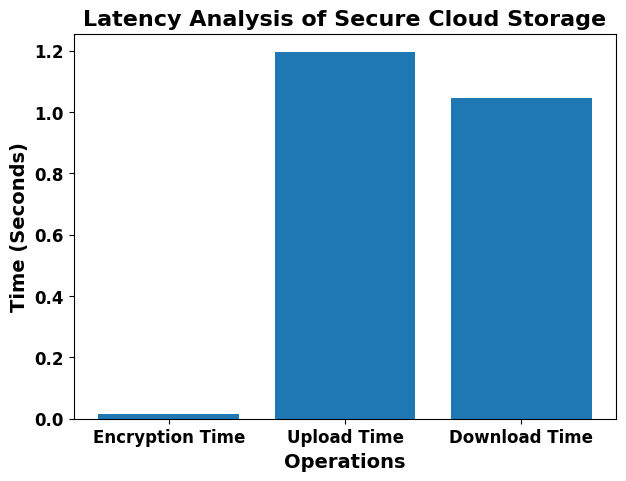

In [35]:
metrics = ['Encryption Time', 'Upload Time', 'Download Time']
values = [encryption_time, upload_time, download_time]

plt.figure(figsize=(7,5))
plt.bar(metrics, values)

plt.xlabel("Operations", fontsize=14, fontweight='bold')
plt.ylabel("Time (Seconds)", fontsize=14, fontweight='bold')
plt.title("Latency Analysis of Secure Cloud Storage", fontsize=16, fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.show()


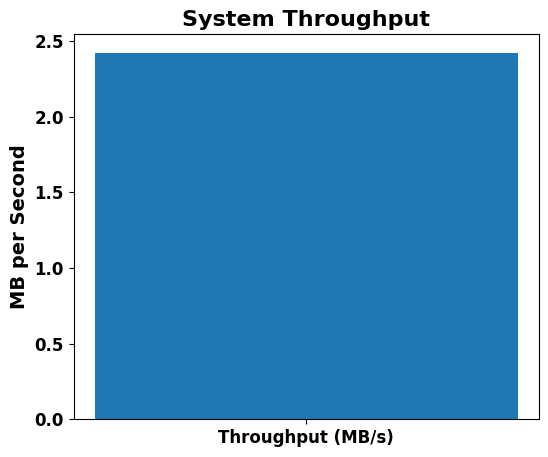

In [36]:
plt.figure(figsize=(6,5))
plt.bar(['Throughput (MB/s)'], [throughput])

plt.ylabel("MB per Second", fontsize=14, fontweight='bold')
plt.title("System Throughput", fontsize=16, fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.show()



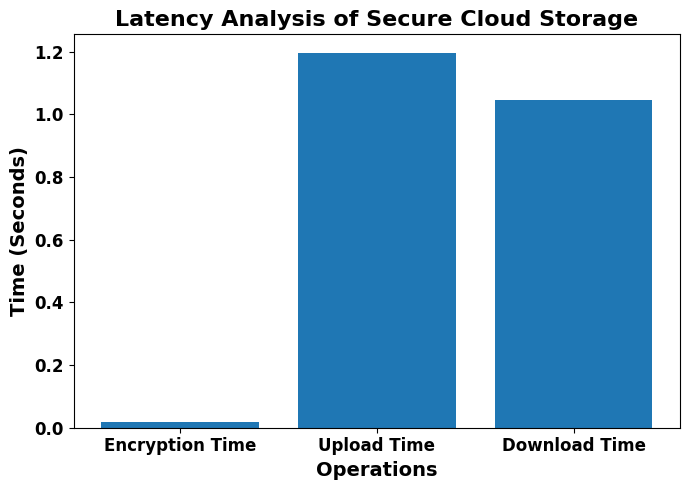

In [37]:
plt.figure(figsize=(7,5))
plt.bar(metrics, values)

plt.xlabel("Operations", fontsize=14, fontweight='bold')
plt.ylabel("Time (Seconds)", fontsize=14, fontweight='bold')
plt.title("Latency Analysis of Secure Cloud Storage", fontsize=16, fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.tight_layout()
plt.savefig("latency_analysis.png", dpi=300, format='png')
plt.show()


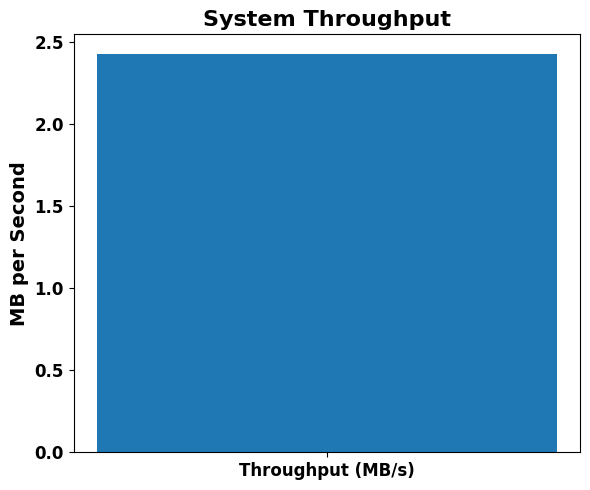

In [38]:
plt.figure(figsize=(6,5))
plt.bar(['Throughput (MB/s)'], [throughput])

plt.ylabel("MB per Second", fontsize=14, fontweight='bold')
plt.title("System Throughput", fontsize=16, fontweight='bold')

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

plt.tight_layout()
plt.savefig("throughput_analysis.png", dpi=300, format='png')
plt.show()
